# Twist and jumps
Understanding the jumps in adj_close_price and how to handle them.

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import skew, kurtosis, probplot
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
print('Libraries loaded.')

Libraries loaded.


In [77]:
# ── DATA LOADING & STATISTICS HELPERS ─────────────────────────────────────

def extract_ticker(filename):
    # text between first and second underscore in the stem
    parts = Path(filename).stem.split('_')
    return parts[1] if len(parts) > 1 else Path(filename).stem


def load_csvs(folder, value_col):
    folder = Path(folder)
    data = {}
    for csv_file in sorted(folder.glob('*.csv')):
        ticker = extract_ticker(csv_file.name)
        df = pd.read_csv(csv_file)
        df['date'] = pd.to_datetime(df['date'])
        df = df.set_index('date').sort_index()
        data[ticker] = df[value_col]
    print(f'Loaded {len(data)} tickers from: {folder}')
    return data


def analyze_nans(data_dict):
    rows = [{'Ticker': t, 'NaN Count': int(s.isna().sum())} for t, s in data_dict.items()]
    nan_df = pd.DataFrame(rows)
    has_nans = nan_df[nan_df['NaN Count'] > 0]
    if has_nans.empty:
        print('No NaN values found in any ticker.')
    else:
        print(f'Tickers with NaN values ({len(has_nans)} of {len(data_dict)}):')
        print(has_nans.to_string(index=False))
    print(f'Total NaNs across all tickers: {nan_df["NaN Count"].sum()}')
    return {t: s.dropna() for t, s in data_dict.items()}


def compute_ticker_stats(series, ticker):
    vals = series.values
    desc = series.describe()
    return {
        'ticker':   ticker,
        'count':    desc['count'],
        'mean':     desc['mean'],
        'std':      desc['std'],
        'min':      desc['min'],
        'q25':      desc['25%'],
        'median':   desc['50%'],
        'q75':      desc['75%'],
        'max':      desc['max'],
        'skewness': float(skew(vals)),
        'kurtosis': float(kurtosis(vals)),
    }


def compute_all_stats(data_dict):
    rows = [compute_ticker_stats(s, t) for t, s in data_dict.items()]
    return pd.DataFrame(rows).set_index('ticker')


def compute_returns(data_dict):
    result = {t: np.log(s / s.shift(1)).dropna() for t, s in data_dict.items()}
    print(f'Log-returns computed for {len(result)} tickers (first row dropped).')
    return result

def compute_increments(data_dict):
    result = {t: (s - s.shift(1)).dropna() for t, s in data_dict.items()}
    print(f'Relative returns computed for {len(result)} tickers (first row dropped).')
    return result


def normalize_individually(data_dict):
    result = {}
    for t, s in data_dict.items():
        mu, sigma = s.mean(), s.std()
        result[t] = (s - mu) / sigma if sigma > 0 else s - mu
    print(f'Z-score normalised {len(result)} tickers individually.')
    return result


def window_normalize(data_dict, window_size):
    result = {}
    for t, s in data_dict.items():
        rm = s.rolling(window=window_size, min_periods=window_size).mean()
        rs = s.rolling(window=window_size, min_periods=window_size).std()
        result[t] = ((s - rm) / rs).dropna()
    dropped = sum(len(data_dict[t]) - len(result[t]) for t in result)
    print(f'Window-wise normalisation (window={window_size}): dropped {dropped} leading obs total.')
    return result


print('Data helpers defined.')

Data helpers defined.


In [78]:
def compute_jumps(data_dict, jump_size):
    """
    Counts jumps per ticker where abs(price_t - price_{t-1}) > price_{t-1} * jump_size.
    Returns a full Series (sorted desc) and the top-10 tickers.
    """
    jump_counts = {}
    for ticker, series in data_dict.items():
        prev = series.shift(1).dropna()
        curr = series.loc[prev.index]
        jump_counts[ticker] = int(((curr - prev).abs() > prev * jump_size).sum())

    jump_series = pd.Series(jump_counts).sort_values(ascending=False)
    top10 = jump_series.head(10)
    print(f"\njump_size={jump_size:.4f}  |  total jumps: {jump_series.sum():,}  |  avg per ticker: {jump_series.mean():.2f}")
    print("Top 10 tickers by jump count:")
    print(top10.to_string())
    return jump_series, top10


# Example call
# _ = compute_jumps(raw_clean, jump_size=0.05)

def compute_trim_counts(data_dict, percentage):
    """
    For each ticker, counts observations outside the
    [percentage/2, 1 - percentage/2] quantile band.
    Returns a full Series (sorted desc) and the top-10 tickers.

    Example: percentage=0.02 removes values below the 1st percentile
             and above the 99th percentile.
    """
    lo_q = percentage / 2
    hi_q = 1.0 - percentage / 2
    trim_counts = {}
    for ticker, series in data_dict.items():
        lo = series.quantile(lo_q)
        hi = series.quantile(hi_q)
        trim_counts[ticker] = int(((series < lo) | (series > hi)).sum())

    trim_series = pd.Series(trim_counts).sort_values(ascending=False)
    top10 = trim_series.head(10)
    pct_str = f'{percentage * 100:.3g}%'
    print(f"\npercentage={pct_str}  |  total records removed: {trim_series.sum():,}  |  avg per ticker: {trim_series.mean():.2f}")
    print(f"  (lower tail < {lo_q*100:.3g}%-quantile,  upper tail > {hi_q*100:.3g}%-quantile)")
    print("Top 10 tickers by records removed:")
    print(top10.to_string())
    return trim_series, top10


# # Example call
# _ = compute_trim_counts(raw_clean, percentage=0.02)



In [111]:
# ── VISUALISATION & ANALYSIS HELPERS ──────────────────────────────────────

def describe_stats(stats_df, label=''):
    sep = '=' * 65
    print(f'\n{sep}')
    print(f'Distribution of per-ticker statistics  [{label}]')
    print(sep)
    print(stats_df.describe().round(6).to_string())


def plot_stat_histograms(stats_df, label='', bins=30):
    cols = list(stats_df.columns)
    n = len(cols)
    ncols = 4
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows), squeeze=False)
    axes_flat = axes.flatten()
    for i, col in enumerate(cols):
        axes_flat[i].hist(stats_df[col].dropna(), bins=bins, edgecolor='black', alpha=0.7, color='steelblue')
        axes_flat[i].set_title(col)
        axes_flat[i].set_xlabel('Value')
        axes_flat[i].set_ylabel('Count')
    for j in range(n, len(axes_flat)):
        axes_flat[j].set_visible(False)
    fig.suptitle(f'Per-ticker statistics distributions  [{label}]', fontsize=13)
    plt.tight_layout()
    plt.show()


def quantile_filter(stats_df, quantile_level=0.9):
    thresholds = stats_df.quantile(quantile_level)
    pct = f'{quantile_level:.0%}'
    print(f'\n{pct}-quantile thresholds per statistic:')
    print(thresholds.round(6).to_string())
    mask = (stats_df > thresholds).any(axis=1)
    outliers_any = stats_df[mask].copy()
    print(f'\nTickers exceeding at least one {pct} threshold: {len(outliers_any)}')
    print(outliers_any.round(4).to_string())

    mask = (stats_df > thresholds).all(axis=1)
    outliers_all = stats_df[mask].copy()
    print(f'\nTickers exceeding all {pct} threshold: {len(outliers_all)}')
    print(outliers_all.round(4).to_string())

    return outliers_any, outliers_all


def plot_ticker_histograms(data_dict, tickers, label='', bins=50):
    found   = [t for t in tickers if t in data_dict]
    missing = [t for t in tickers if t not in data_dict]
    if missing:
        print(f'Tickers not found: {missing}')
    for ticker in found:
        s = data_dict[ticker].dropna()
        stats = s.describe()
        stats['skewness'] = skew(s.values)
        stats['kurtosis'] = kurtosis(s.values)
        print(f'\n── {ticker}  [{label}] ──')
        print(stats.round(6).to_string())

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

        ax1.hist(s, bins=bins, edgecolor='black', alpha=0.7, color='darkorange')
        ax1.set_title(f'{ticker}  [{label}]')
        ax1.set_xlabel('Value')
        ax1.set_ylabel('Count')

        ax2.scatter(s.index, s.values, s=2, alpha=0.5, color='steelblue')
        ax2.set_title(f'{ticker}  [{label}] — time series')
        ax2.set_xlabel('Date')
        ax2.set_ylabel('Value')

        plt.tight_layout()
        plt.show()





def compute_aggregate_stats_and_plot(data_dict, label='', bins=200):
    all_vals = np.concatenate([s.dropna().values for s in data_dict.values()])
    agg = {
        'count':    len(all_vals),
        'mean':     float(np.mean(all_vals)),
        'std':      float(np.std(all_vals)),
        'min':      float(np.min(all_vals)),
        'q25':      float(np.percentile(all_vals, 25)),
        'median':   float(np.median(all_vals)),
        'q75':      float(np.percentile(all_vals, 75)),
        'max':      float(np.max(all_vals)),
        'skewness': float(skew(all_vals)),
        'kurtosis': float(kurtosis(all_vals)),
    }
    sep = '=' * 55
    print(f'\n{sep}')
    print(f'Aggregate statistics  [{label}]  (N={agg["count"]:,})')
    print(sep)
    for k, v in agg.items():
        print(f'  {k:<12}: {int(v):,}' if k == 'count' else f'  {k:<12}: {v:.6g}')
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.hist(all_vals, bins=bins, density=True, alpha=0.7, color='mediumseagreen', edgecolor='none')
    ax1.set_title(f'Aggregate distribution  [{label}]')
    ax1.set_xlabel('Value')
    ax1.set_ylabel('Density')
    (osm, osr), (slope, intercept, _r) = probplot(all_vals, dist='norm')
    ax2.scatter(osm, osr, s=0.5, alpha=0.3, color='steelblue')
    ax2.plot([osm[0], osm[-1]], [slope * osm[0] + intercept, slope * osm[-1] + intercept],
             color='red', lw=1.5, label='Normal fit')
    ax2.set_title(f'Q-Q vs Normal  [{label}]')
    ax2.set_xlabel('Theoretical quantiles')
    ax2.set_ylabel('Sample quantiles')
    ax2.legend()
    plt.tight_layout()
    plt.show()
    return agg


def compute_aggregate_stats_and_plot_std(data_dict, label='', n_stds=2, bins_per_std=100):
    """Like compute_aggregate_stats_and_plot, but bin edges are defined in units of std.
    
    n_stds      : how many std deviations to cover on each side of the mean
    bins_per_std: number of bins per std unit (total bins = 2 * n_stds * bins_per_std)
    """
    all_vals = np.concatenate([s.dropna().values for s in data_dict.values()])
    mu    = float(np.mean(all_vals))
    sigma = float(np.std(all_vals))

    agg = {
        'count':    len(all_vals),
        'mean':     mu,
        'std':      sigma,
        'min':      float(np.min(all_vals)),
        'q25':      float(np.percentile(all_vals, 25)),
        'median':   float(np.median(all_vals)),
        'q75':      float(np.percentile(all_vals, 75)),
        'max':      float(np.max(all_vals)),
        'skewness': float(skew(all_vals)),
        'skewness': float(kurtosis(all_vals)),
    }
    sep = '=' * 55
    print(f'\n{sep}')
    print(f'Aggregate statistics  [{label}]  (N={agg["count"]:,})')
    print(sep)
    for k, v in agg.items():
        print(f'  {k:<12}: {int(v):,}' if k == 'count' else f'  {k:<12}: {v:.6g}')

    # bin edges at regular std intervals
    bin_edges = np.linspace(mu - n_stds * sigma, mu + n_stds * sigma,
                            num=2 * n_stds * bins_per_std + 1)
    # std-unit tick positions and labels for the x-axis
    std_ticks  = np.arange(-n_stds, n_stds + 1)
    std_labels = [f'{k:+d}σ' if k != 0 else 'μ' for k in std_ticks]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.hist(all_vals, bins=bin_edges, density=True, alpha=0.7,
             color='mediumseagreen', edgecolor='none')
    ax1.set_xticks(mu + std_ticks * sigma)
    ax1.set_xticklabels(std_labels)
    ax1.set_xlim(bin_edges[0], bin_edges[-1])
    ax1.set_title(f'Aggregate distribution  [{label}]')
    ax1.set_xlabel(f'Value  (bin width = σ/{bins_per_std})')
    ax1.set_ylabel('Density')

    (osm, osr), (slope, intercept, _r) = probplot(all_vals, dist='norm')
    ax2.scatter(osm, osr, s=0.5, alpha=0.3, color='steelblue')
    ax2.plot([osm[0], osm[-1]], [slope * osm[0] + intercept, slope * osm[-1] + intercept],
             color='red', lw=1.5, label='Normal fit')
    ax2.set_title(f'Q-Q vs Normal  [{label}]')
    ax2.set_xlabel('Theoretical quantiles')
    ax2.set_ylabel('Sample quantiles')
    ax2.legend()

    plt.tight_layout()
    plt.show()
    return agg


print('Visualisation helpers defined.')

Visualisation helpers defined.


---
## Section 1 — Loading the data

Data folder: `../data/raw_replication`  |  Column: `adj_close`

In [80]:
# 1.1  Load
raw_data = load_csvs('../data/raw_replication', 'adj_close')
log_data = load_csvs('../data/log_replication', 'log_adj_close')
print("Lenght of raw_data:", len(raw_data), "Lenght of log_data:", len(log_data))

raw_clean = analyze_nans(raw_data)
log_clean = analyze_nans(log_data)
print("Lenght of raw_clean:", len(raw_clean), "Lenght of log_clean:", len(log_clean))

returns_data = compute_returns(raw_clean)
increments_data = compute_increments(raw_clean)
print("Lenght of returns_data:", len(returns_data), "Lenght of increments_data:", len(increments_data))

returns_clean = analyze_nans(returns_data)
increments_clean = analyze_nans(increments_data)
print("Lenght of returns_clean:", len(returns_clean), "Lenght of increments_clean:", len(increments_clean))

Loaded 214 tickers from: ..\data\raw_replication
Loaded 214 tickers from: ..\data\log_replication
Lenght of raw_data: 214 Lenght of log_data: 214
No NaN values found in any ticker.
Total NaNs across all tickers: 0
No NaN values found in any ticker.
Total NaNs across all tickers: 0
Lenght of raw_clean: 214 Lenght of log_clean: 214
Log-returns computed for 214 tickers (first row dropped).
Relative returns computed for 214 tickers (first row dropped).
Lenght of returns_data: 214 Lenght of increments_data: 214
No NaN values found in any ticker.
Total NaNs across all tickers: 0
No NaN values found in any ticker.
Total NaNs across all tickers: 0
Lenght of returns_clean: 214 Lenght of increments_clean: 214


In [81]:
raw_stats = compute_all_stats(raw_clean)
# describe_stats(raw_stats, 'Daily Prices')

log_stats = compute_all_stats(log_clean)
# describe_stats(log_stats, 'Daily Log-Prices')

In [82]:
return_stats = compute_all_stats(returns_clean)
# describe_stats(return_stats, 'Daily Log-Returns')

increments_stats = compute_all_stats(increments_clean)
# describe_stats(increments_stats, 'Daily Log-increments')

# Jump analysis

In [83]:
_ = compute_jumps(raw_clean, jump_size=1.0)


jump_size=1.0000  |  total jumps: 4  |  avg per ticker: 0.02
Top 10 tickers by jump count:
BEN     1
HUBB    1
NVR     1
WMB     1
NKE     0
NOC     0
NSC     0
NTRS    0
NUE     0
OKE     0


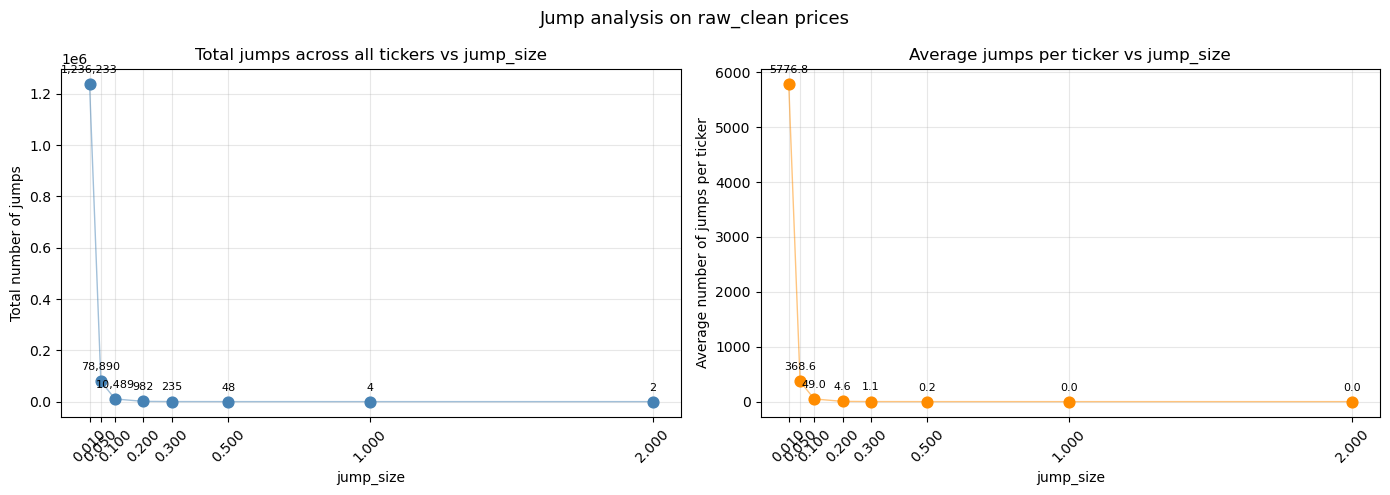

In [84]:
jump_sizes = [0.01, 0.05, 0.10, 0.20, 0.30, 0.5, 1.0, 2.0]

total_jumps  = []
avg_jumps    = []

for js in jump_sizes:
    counts = {}
    for ticker, series in raw_clean.items():
        prev = series.shift(1).dropna()
        curr = series.loc[prev.index]
        counts[ticker] = int(((curr - prev).abs() > prev * js).sum())
    s = pd.Series(counts)
    total_jumps.append(s.sum())
    avg_jumps.append(s.mean())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(jump_sizes, total_jumps, color='steelblue', s=60, zorder=3)
ax1.plot(jump_sizes, total_jumps, color='steelblue', alpha=0.5, lw=1)
for x, y in zip(jump_sizes, total_jumps):
    ax1.annotate(f'{y:,}', (x, y), textcoords='offset points', xytext=(0, 8),
                 ha='center', fontsize=8)
ax1.set_title('Total jumps across all tickers vs jump_size')
ax1.set_xlabel('jump_size')
ax1.set_ylabel('Total number of jumps')
ax1.set_xticks(jump_sizes)
ax1.set_xticklabels([f'{js:.3f}' for js in jump_sizes], rotation=45)

ax2.scatter(jump_sizes, avg_jumps, color='darkorange', s=60, zorder=3)
ax2.plot(jump_sizes, avg_jumps, color='darkorange', alpha=0.5, lw=1)
for x, y in zip(jump_sizes, avg_jumps):
    ax2.annotate(f'{y:.1f}', (x, y), textcoords='offset points', xytext=(0, 8),
                 ha='center', fontsize=8)
ax2.set_title('Average jumps per ticker vs jump_size')
ax2.set_xlabel('jump_size')
ax2.set_ylabel('Average number of jumps per ticker')
ax2.set_xticks(jump_sizes)
ax2.set_xticklabels([f'{js:.3f}' for js in jump_sizes], rotation=45)

plt.suptitle('Jump analysis on raw_clean prices', fontsize=13)
plt.tight_layout()
plt.show()


 ### Removing some of the biggest jump datasets
 In particular are 4 those datasets that have jumps bigger than 100%, for a total of 4 jumps (one each):
 * BEN
 * HUBB
 * NVR
 * WMB

In [85]:
quantile_level = 0.9

In [86]:
# raw_stats = compute_all_stats(raw_clean)
describe_stats(raw_stats, 'Daily Prices')

raw_outliers_any, raw_outliers_all = quantile_filter(raw_stats, quantile_level)
print("")


Distribution of per-ticker statistics  [Daily Prices]
              count         mean          std         min         q25      median          q75          max    skewness    kurtosis
count    214.000000   214.000000   214.000000  214.000000  214.000000  214.000000   214.000000   214.000000  214.000000  214.000000
mean   12473.322430    39.815772    57.360989    0.500109    3.023012   15.188477    49.918034   279.572409    1.698212    2.935342
std     1698.796946    97.176360   149.820808    0.643057    2.952224   35.067905   111.305106   701.068427    0.740545    4.789746
min    10084.000000     4.609644     3.839570    0.001410    0.025950    0.497044     6.576248    19.003372    0.269990   -1.440364
25%    11469.250000    16.925054    19.779750    0.115278    1.178369    7.245811    21.974833    86.536631    1.237979    0.391497
50%    11611.000000    26.997282    36.119734    0.314991    2.414969   10.623137    36.643080   167.867485    1.614612    1.711619
75%    13397.000000  

In [87]:
# print("Std outliers")
# raw_outliers_any[raw_outliers_any['std'] > raw_stats['std'].quantile(quantile_level)].sort_values('std',ascending = False).head(3)

In [99]:
# print("Skewness outliers")
# raw_outliers_any[raw_outliers_any['skewness'] > raw_stats['skewness'].quantile(quantile_level)].sort_values('skewness',ascending = False).head(3)

In [100]:

# print("Kurtosis outliers")
# raw_outliers_any[raw_outliers_any['kurtosis'] > raw_stats['kurtosis'].quantile(quantile_level)].sort_values('kurtosis',ascending = False).head(3)

In [90]:
# describe_stats(increments_stats, 'Daily Log-increments')
# return_stats = compute_all_stats(returns_clean)
describe_stats(return_stats, 'Daily Log-Returns')

return_outliers_any, return_outliers_all = quantile_filter(return_stats, quantile_level)
print("")


Distribution of per-ticker statistics  [Daily Log-Returns]
              count        mean         std         min         q25      median         q75         max    skewness     kurtosis
count    214.000000  214.000000  214.000000  214.000000  214.000000  214.000000  214.000000  214.000000  214.000000   214.000000
mean   12472.322430    0.000460    0.020710   -0.320949   -0.009040    0.000004    0.009931    0.254179   -0.161779    66.061340
std     1698.796946    0.000132    0.005811    0.184631    0.002515    0.000036    0.002422    0.277431    4.881536   430.675809
min    10083.000000    0.000129    0.012167   -1.525526   -0.019802    0.000000    0.002909    0.102049  -10.238005     3.741907
25%    11468.250000    0.000384    0.017020   -0.359621   -0.010000    0.000000    0.008237    0.164543   -0.585283     8.518035
50%    11610.000000    0.000460    0.019550   -0.267534   -0.008582    0.000000    0.009534    0.200034   -0.268473    13.324422
75%    13396.000000    0.000533    0.

In [91]:
# increments_stats = compute_all_stats(increments_clean)
describe_stats(increments_stats, 'Daily Log-increments')
increments_outliers_any, increments_outliers_all = quantile_filter(increments_stats, quantile_level)
print("")


Distribution of per-ticker statistics  [Daily Log-increments]
              count        mean         std         min         q25      median         q75         max    skewness     kurtosis
count    214.000000  214.000000  214.000000  214.000000  214.000000  214.000000  214.000000  214.000000  214.000000   214.000000
mean   12472.322430    0.018317    1.248769  -24.071935   -0.099318    0.000032    0.128542   20.100727   -0.760842    69.839960
std     1698.796946    0.046898    3.173187   47.494365    0.206418    0.000402    0.282711   39.497191    2.229741   110.113326
min    10083.000000    0.000878    0.134478 -600.500000   -2.959995    0.000000    0.008328    1.545078  -20.149094     9.040075
25%    11468.250000    0.005369    0.431501  -24.800411   -0.116731    0.000000    0.055543    6.574421   -1.226961    31.372810
50%    11610.000000    0.009500    0.792144  -13.593843   -0.073206    0.000000    0.096416   11.269924   -0.553752    48.451796
75%    13396.000000    0.020968   

In [92]:
raw_filtered = raw_clean.copy()
raw_filtered.pop('BEN')
raw_filtered.pop('HUBB')
raw_filtered.pop('NVR')
raw_filtered.pop('WMB')
print("")

In [93]:
returns_filtered = returns_clean.copy()
returns_filtered.pop('BEN')
returns_filtered.pop('HUBB')
returns_filtered.pop('NVR')
returns_filtered.pop('WMB')

increments_filtered = increments_clean.copy()
increments_filtered.pop('BEN')
increments_filtered.pop('HUBB')
increments_filtered.pop('NVR')
increments_filtered.pop('WMB')
print("")

In [94]:
raw_stats = compute_all_stats(raw_filtered)
describe_stats(raw_stats, 'Daily Prices Filtered')

raw_outliers_any, raw_outliers_all = quantile_filter(raw_stats, quantile_level)
print("")


Distribution of per-ticker statistics  [Daily Prices Filtered]
              count        mean         std         min         q25      median         q75          max    skewness    kurtosis
count    210.000000  210.000000  210.000000  210.000000  210.000000  210.000000  210.000000   210.000000  210.000000  210.000000
mean   12493.809524   33.501820   47.652487    0.506268    2.974827   12.876072   42.697168   234.559556    1.697442    2.924138
std     1699.903952   24.634673   42.082296    0.647448    2.765973    8.155869   29.271431   230.180371    0.737001    4.813020
min    10084.000000    4.609644    3.839570    0.001410    0.025950    0.497044    6.576248    19.003372    0.373959   -1.440364
25%    11494.250000   17.224999   20.358901    0.115278    1.178369    7.194626   22.064031    86.786425    1.237979    0.391497
50%    11611.000000   26.997282   36.119734    0.323738    2.454899   10.623137   36.643080   167.867485    1.611462    1.674796
75%    13397.000000   43.947694  

In [104]:
returns_stats = compute_all_stats(returns_filtered)
describe_stats(return_stats, 'Daily Log-Returns Filtered')

returns_outliers_any, returns_outliers_all = quantile_filter(returns_stats, quantile_level)
print("")


Distribution of per-ticker statistics  [Daily Log-Returns Filtered]
              count        mean         std         min         q25      median         q75         max    skewness    kurtosis
count    210.000000  210.000000  210.000000  210.000000  210.000000  210.000000  210.000000  210.000000  210.000000  210.000000
mean   12492.809524    0.000458    0.020481   -0.310232   -0.009053    0.000004    0.009940    0.224658   -0.567837   28.035091
std     1699.903952    0.000132    0.005418    0.155030    0.002484    0.000036    0.002388    0.100340    1.371693   48.716877
min    10083.000000    0.000129    0.012167   -0.936258   -0.019802    0.000000    0.006006    0.102049  -10.238005    3.741907
25%    11493.250000    0.000383    0.016929   -0.352553   -0.009944    0.000000    0.008237    0.164169   -0.585283    8.471495
50%    11610.000000    0.000460    0.019455   -0.266636   -0.008565    0.000000    0.009501    0.199278   -0.269322   13.224475
75%    13396.000000    0.000531    

In [96]:
increments_stats = compute_all_stats(increments_filtered)
describe_stats(increments_stats, 'Daily Log-increments Filtered')

increments_outliers_any, increments_outliers_all = quantile_filter(increments_stats, quantile_level)
print("")


Distribution of per-ticker statistics  [Daily Log-increments Filtered]
              count        mean         std         min         q25      median         q75         max    skewness     kurtosis
count    210.000000  210.000000  210.000000  210.000000  210.000000  210.000000  210.000000  210.000000  210.000000   210.000000
mean   12492.809524    0.015312    1.044321  -21.444721   -0.086251    0.000033    0.110251   17.735522   -0.772639    70.446394
std     1699.903952    0.016860    0.951523   26.399588    0.063827    0.000406    0.074992   17.911531    2.249124   111.031130
min    10083.000000    0.000878    0.134478 -256.436768   -0.503279    0.000000    0.008328    1.545078  -20.149094    10.442881
25%    11493.250000    0.005369    0.433435  -24.382442   -0.116731    0.000000    0.055291    6.574421   -1.231155    31.487823
50%    11610.000000    0.009500    0.792144  -13.593843   -0.073295    0.000000    0.098226   11.269924   -0.560278    48.451796
75%    13396.000000    0.

#### Returns additional info

In [105]:
print("Max outliers")
print(returns_outliers_any[returns_outliers_any['max'] > returns_stats['max'].quantile(quantile_level)].sort_values('max',ascending = False).head(10).index)
returns_outliers_any[returns_outliers_any['max'] > returns_stats['max'].quantile(quantile_level)].sort_values('max',ascending = False).head(3)

Max outliers
Index(['MNST', 'PNW', 'DVN', 'PCG', 'COO', 'JKHY', 'AIG', 'CNP', 'DHR',
       'FITB'],
      dtype='object', name='ticker')


,count,mean,std,min,q25,median,q75,max,skewness,kurtosis
ticker,,,,,,,,,,
MNST,10161.0,0.000692,0.046276,-0.693147,-0.009528,0.0,0.010391,0.693147,0.607248,49.528176
PNW,13396.0,0.000239,0.016034,-0.264692,-0.006825,0.0,0.007490,0.645519,4.405478,216.134769
DVN,10258.0,0.000263,0.027935,-0.468359,-0.013086,0.0,0.013884,0.627189,0.655902,39.147261


In [107]:
print("Min outliers")
print(returns_outliers_any[returns_outliers_any['min'] < returns_stats['min'].quantile(quantile_level)].sort_values('min',ascending = True).head(10).index)
returns_outliers_any[returns_outliers_any['min'] < returns_stats['min'].quantile(quantile_level)].sort_values('min',ascending = True).head(3)

Min outliers
Index(['AIG', 'STT', 'TSN', 'VTRS', 'APA', 'GL', 'PCG', 'TRV', 'OXY', 'AAPL'], dtype='object', name='ticker')


,count,mean,std,min,q25,median,q75,max,skewness,kurtosis
ticker,,,,,,,,,,
AIG,13430.0,0.000129,0.027112,-0.936258,-0.008509,0.0,0.009476,0.506818,-3.509373,168.169536
STT,11610.0,0.000627,0.023403,-0.892505,-0.008263,0.0,0.010050,0.272661,-4.642413,195.574711
TSN,11610.0,0.000341,0.024530,-0.843430,-0.009370,0.0,0.010527,0.204593,-7.027838,215.613467


In [108]:
print("Std outliers")
print(returns_outliers_any[returns_outliers_any['std'] > returns_stats['std'].quantile(quantile_level)].sort_values('std',ascending = False).head(10).index)
returns_outliers_any[returns_outliers_any['std'] > returns_stats['std'].quantile(quantile_level)].sort_values('std',ascending = False).head(3)

Std outliers
Index(['MNST', 'SWKS', 'MU', 'WDC', 'AMD', 'LRCX', 'COO', 'TER', 'KLAC',
       'BBY'],
      dtype='object', name='ticker')


,count,mean,std,min,q25,median,q75,max,skewness,kurtosis
ticker,,,,,,,,,,
MNST,10161.0,0.000692,0.046276,-0.693147,-0.009528,0.0,0.010391,0.693147,0.607248,49.528176
SWKS,10477.0,0.000236,0.039122,-0.287682,-0.018637,0.0,0.017682,0.462624,0.455477,8.154327
MU,10545.0,0.000544,0.038035,-0.290923,-0.019802,0.0,0.020587,0.212922,-0.191625,3.859221


In [109]:
print("Skewness outliers")
print(returns_outliers_any[returns_outliers_any['skewness'] > returns_stats['skewness'].quantile(quantile_level)].sort_values('skewness',ascending = False).head(10).index)
returns_outliers_any[returns_outliers_any['skewness'] > returns_stats['skewness'].quantile(quantile_level)].sort_values('skewness',ascending = False).head(3)

Skewness outliers
Index(['PNW', 'D', 'DHR', 'COO', 'DVN', 'MNST', 'JKHY', 'SWKS', 'WFC', 'TPL'], dtype='object', name='ticker')


,count,mean,std,min,q25,median,q75,max,skewness,kurtosis
ticker,,,,,,,,,,
PNW,13396.0,0.000239,0.016034,-0.264692,-0.006825,0.0,0.007490,0.645519,4.405478,216.134769
D,11610.0,0.000443,0.013272,-0.160343,-0.005736,0.0,0.007053,0.382992,1.512722,71.053941
DHR,11916.0,0.000702,0.021980,-0.291054,-0.008734,0.0,0.009583,0.477590,1.014817,26.862981


In [110]:

print("Kurtosis outliers")
print(returns_outliers_any[returns_outliers_any['kurtosis'] > returns_stats['kurtosis'].quantile(quantile_level)].sort_values('kurtosis',ascending = False).head(10).index)
returns_outliers_any[returns_outliers_any['kurtosis'] > returns_stats['kurtosis'].quantile(quantile_level)].sort_values('kurtosis',ascending = False).head(3)

Kurtosis outliers
Index(['GL', 'MRSH', 'MCD', 'TRV', 'PNW', 'TSN', 'STT', 'PCG', 'AIG', 'CNP'], dtype='object', name='ticker')


,count,mean,std,min,q25,median,q75,max,skewness,kurtosis
ticker,,,,,,,,,,
GL,11472.0,0.000408,0.021365,-0.758010,-0.007220,0.0,0.008510,0.183778,-10.238005,353.156689
MRSH,13396.0,0.000391,0.016900,-0.725937,-0.006973,0.0,0.007815,0.134800,-6.349732,265.751315
MCD,15040.0,0.000526,0.019043,-0.707640,-0.008109,0.0,0.008889,0.166577,-6.768575,250.572891



── GL  [Daily Log-Returns] ──
count       11472.000000
mean            0.000408
std             0.021365
min            -0.758010
25%            -0.007220
50%             0.000000
75%             0.008510
max             0.183778
skewness      -10.238005
kurtosis      353.156689


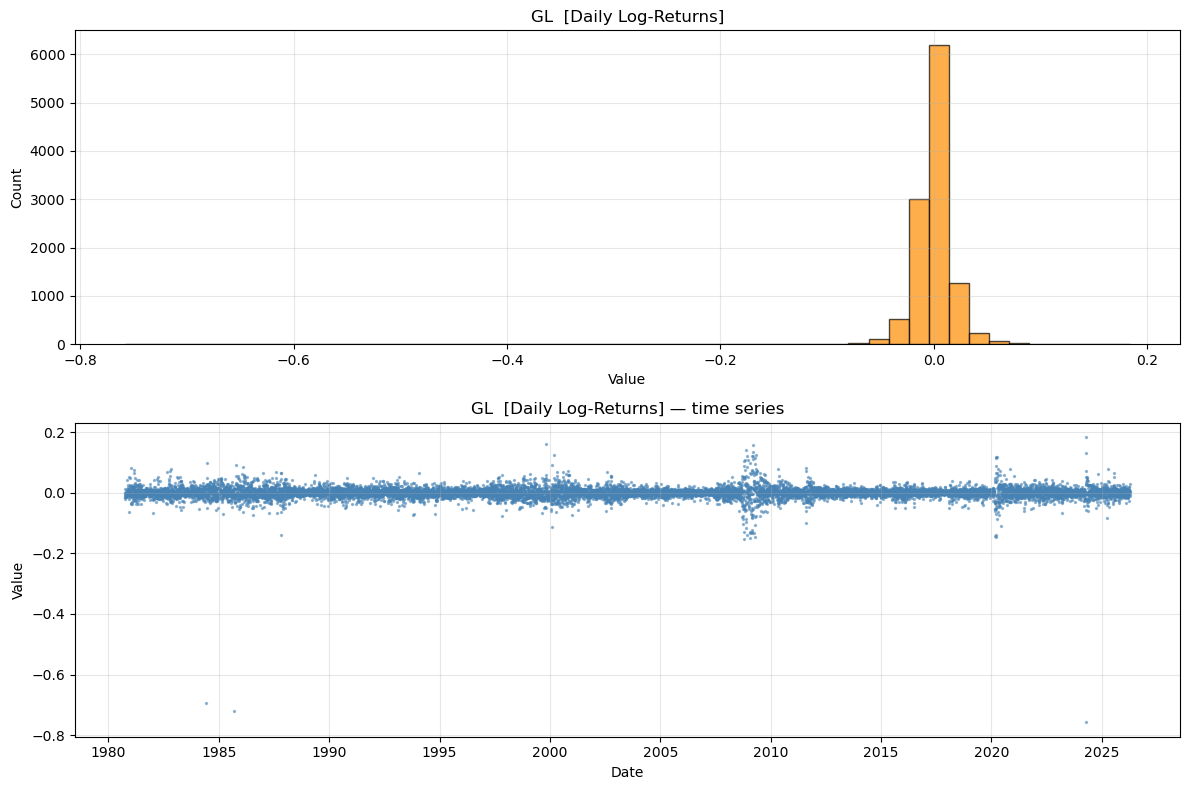


── MNST  [Daily Log-Returns] ──
count       10161.000000
mean            0.000692
std             0.046276
min            -0.693147
25%            -0.009528
50%             0.000000
75%             0.010391
max             0.693147
skewness        0.607248
kurtosis       49.528176


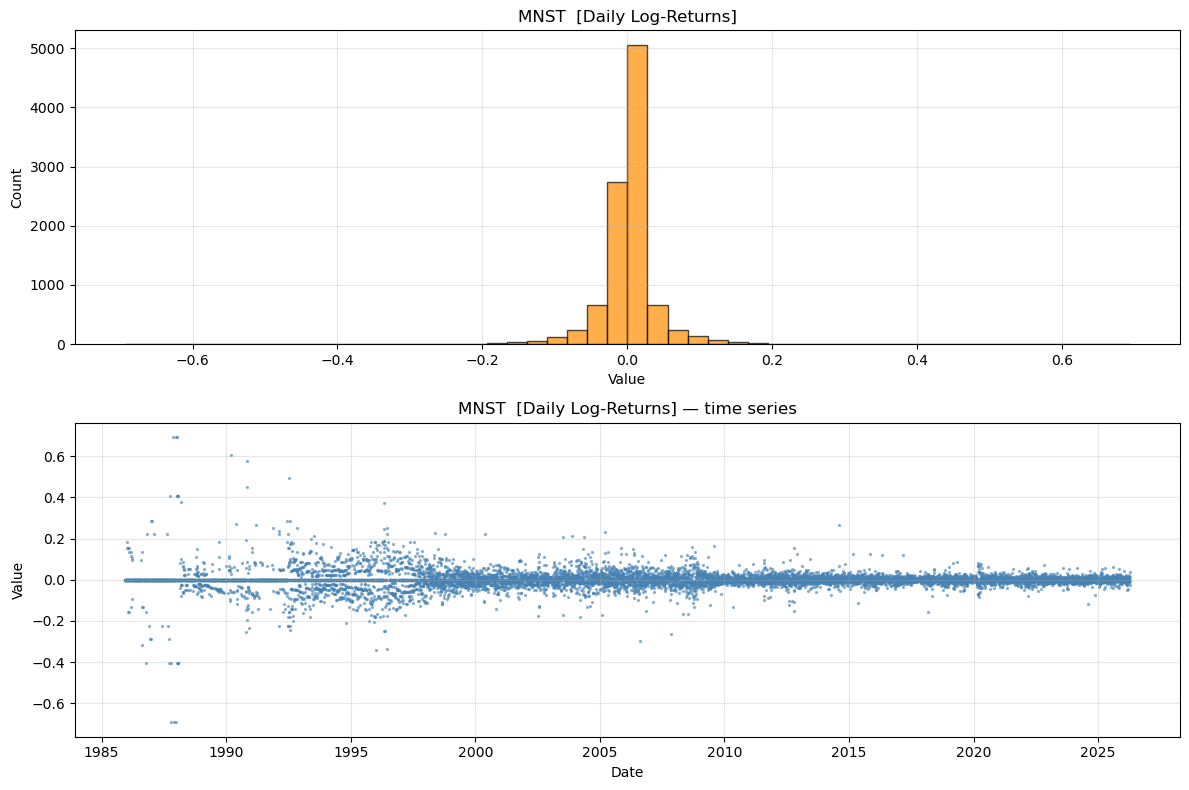


── D  [Daily Log-Returns] ──
count       11610.000000
mean            0.000443
std             0.013272
min            -0.160343
25%            -0.005736
50%             0.000000
75%             0.007053
max             0.382992
skewness        1.512722
kurtosis       71.053941


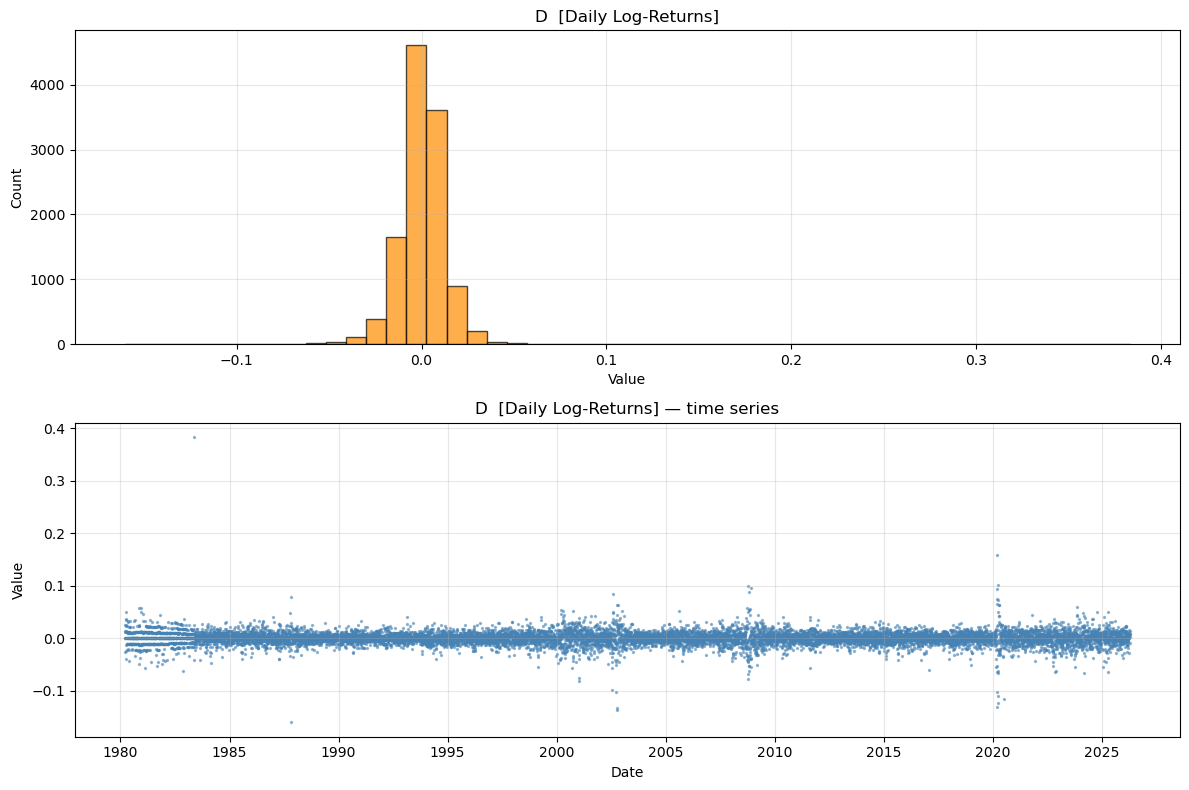


── MRSH  [Daily Log-Returns] ──
count       13396.000000
mean            0.000391
std             0.016900
min            -0.725937
25%            -0.006973
50%             0.000000
75%             0.007815
max             0.134800
skewness       -6.349732
kurtosis      265.751315


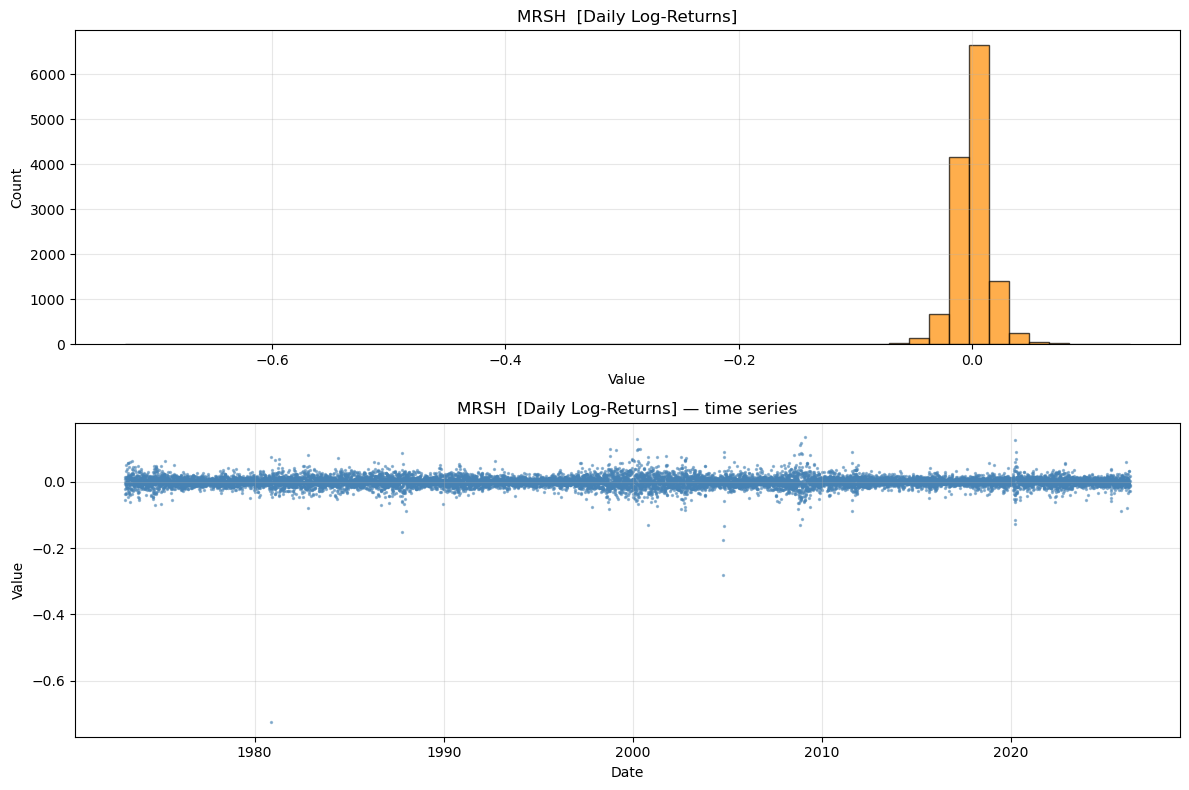


── AIG  [Daily Log-Returns] ──
count       13430.000000
mean            0.000129
std             0.027112
min            -0.936258
25%            -0.008509
50%             0.000000
75%             0.009476
max             0.506818
skewness       -3.509373
kurtosis      168.169536


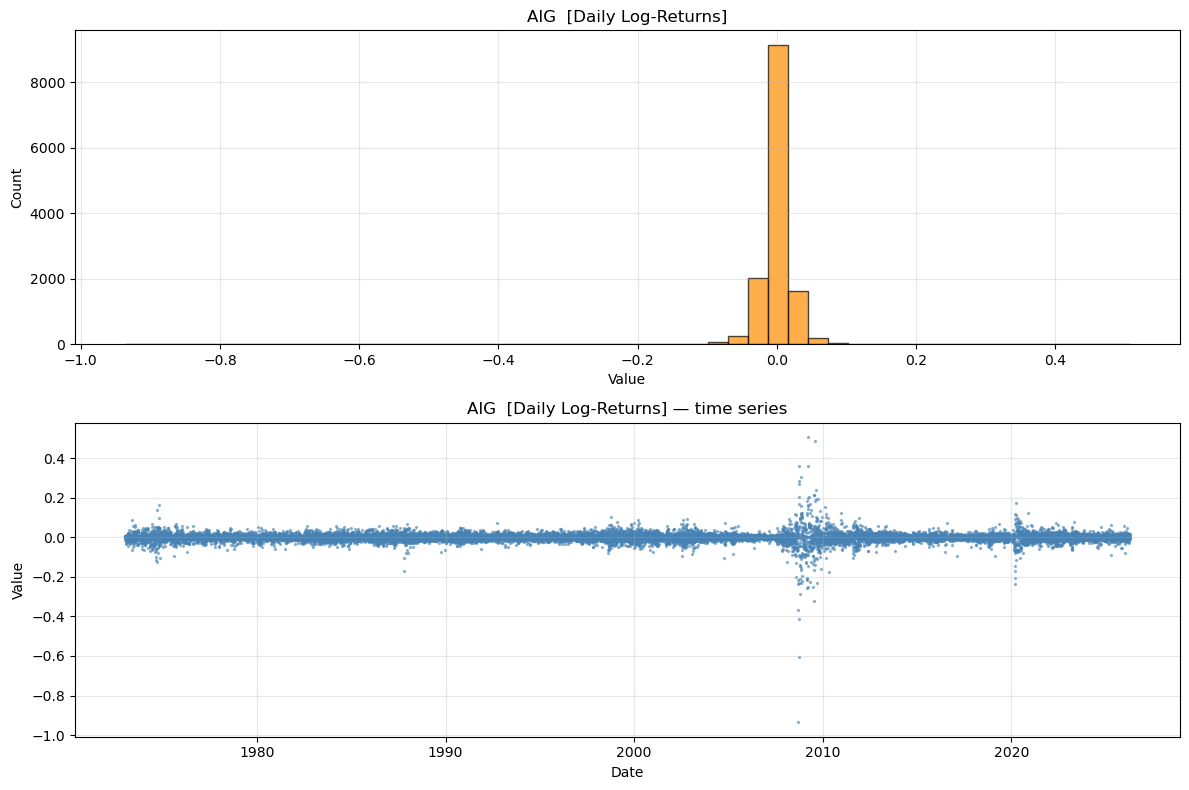

In [113]:
# 3.7  Ticker histograms
tickers_to_plot = ['GL', 'MNST', 'D', 'MRSH', 'AIG']  # ← SET

plot_ticker_histograms(returns_filtered, tickers_to_plot, 'Daily Log-Returns')

# Quantile analysis

In [97]:
# Example call
# _ = compute_trim_counts(raw_clean, percentage=1.0)

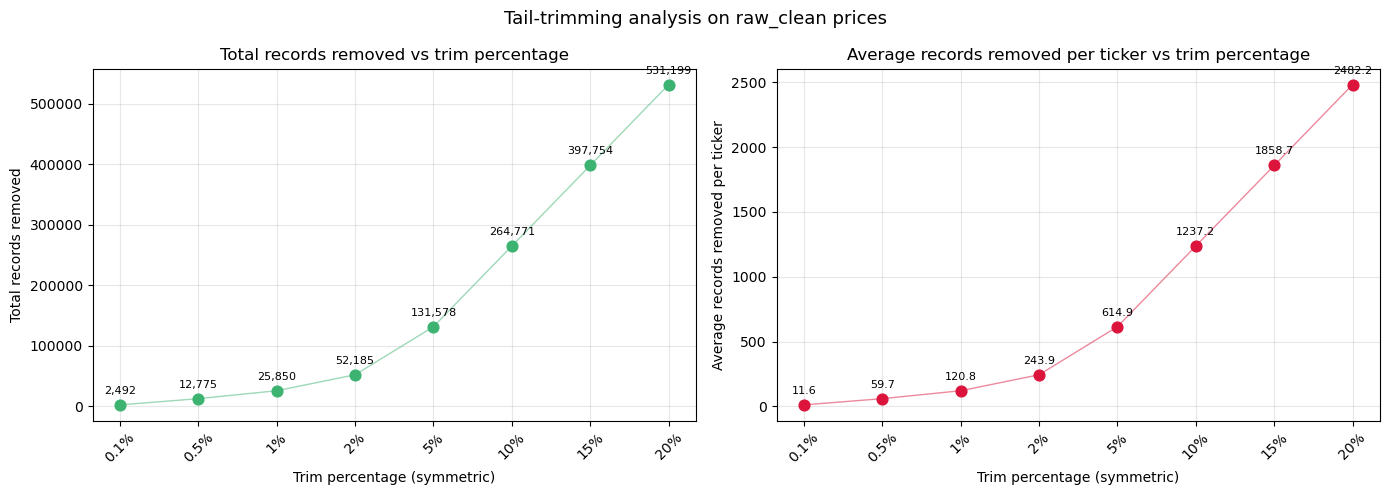

In [98]:
percentages = [0.001, 0.005, 0.01, 0.02, 0.05, 0.10, 0.15, 0.20]

total_removed = []
avg_removed   = []

for pct in percentages:
    lo_q, hi_q = pct / 2, 1.0 - pct / 2
    counts = {}
    for ticker, series in raw_clean.items():
        lo = series.quantile(lo_q)
        hi = series.quantile(hi_q)
        counts[ticker] = int(((series < lo) | (series > hi)).sum())
    s = pd.Series(counts)
    total_removed.append(s.sum())
    avg_removed.append(s.mean())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
pct_labels = [f'{p*100:.3g}%' for p in percentages]

ax1.scatter(range(len(percentages)), total_removed, color='mediumseagreen', s=60, zorder=3)
ax1.plot(range(len(percentages)), total_removed, color='mediumseagreen', alpha=0.5, lw=1)
for i, y in enumerate(total_removed):
    ax1.annotate(f'{y:,}', (i, y), textcoords='offset points', xytext=(0, 8),
                 ha='center', fontsize=8)
ax1.set_xticks(range(len(percentages)))
ax1.set_xticklabels(pct_labels, rotation=45)
ax1.set_title('Total records removed vs trim percentage')
ax1.set_xlabel('Trim percentage (symmetric)')
ax1.set_ylabel('Total records removed')

ax2.scatter(range(len(percentages)), avg_removed, color='crimson', s=60, zorder=3)
ax2.plot(range(len(percentages)), avg_removed, color='crimson', alpha=0.5, lw=1)
for i, y in enumerate(avg_removed):
    ax2.annotate(f'{y:.1f}', (i, y), textcoords='offset points', xytext=(0, 8),
                 ha='center', fontsize=8)
ax2.set_xticks(range(len(percentages)))
ax2.set_xticklabels(pct_labels, rotation=45)
ax2.set_title('Average records removed per ticker vs trim percentage')
ax2.set_xlabel('Trim percentage (symmetric)')
ax2.set_ylabel('Average records removed per ticker')

plt.suptitle('Tail-trimming analysis on raw_clean prices', fontsize=13)
plt.tight_layout()
plt.show()
